In [1]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
from collections import defaultdict

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)
plt.rcParams['legend.title_fontsize'] = 'small'

In [3]:
# Load data, models

datasets = ["Bherer"]
model_names = [
    "alt_los",
    "alt_stu",
    "alt_ust",
    "cha_los",
    "cha_stu",
    "cha_ust",
    "vin_los",
    "vin_stu",
    "vin_ust",
]

u = 1.3e-8

datas = {}
models = {}
params = {}

for dataset in datasets:
    data_file = f"../../../analyses/recombination_maps/stats/subset_{dataset}.pkl"
    for model in model_names:
        graph = f"results/{model}_{dataset}.yaml"
        param_file = f"models/{model}_params.yaml"
        data = dpluspy.inference.load_bootstrap_reps(
            data_file, graph=graph, return_dict=True)
        datas[(model, dataset)] = data
        models[(model, dataset)] = dpluspy.inference.compute_bin_stats(
            graph, sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
        params[(model, dataset)] = dpluspy.inference._load_params(
            graph, param_file)

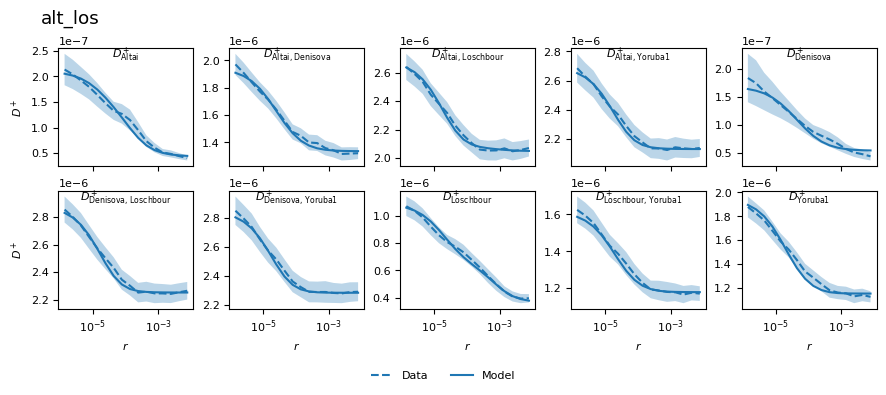

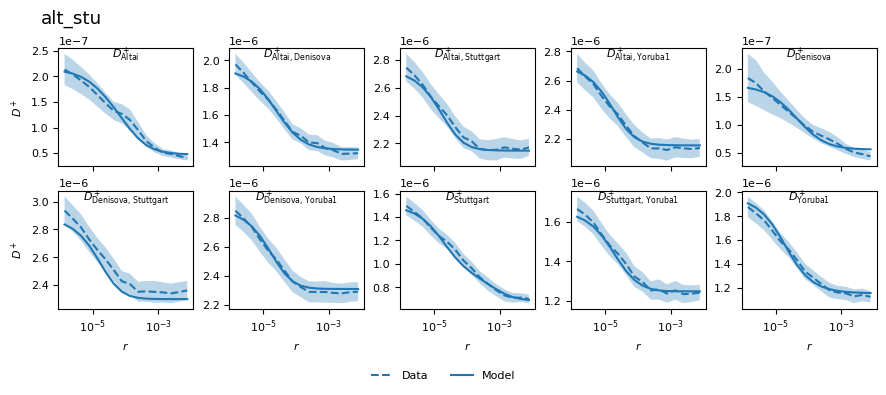

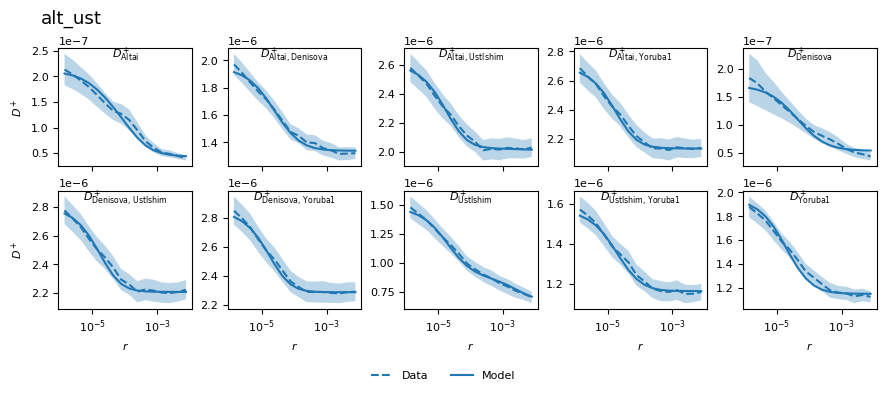

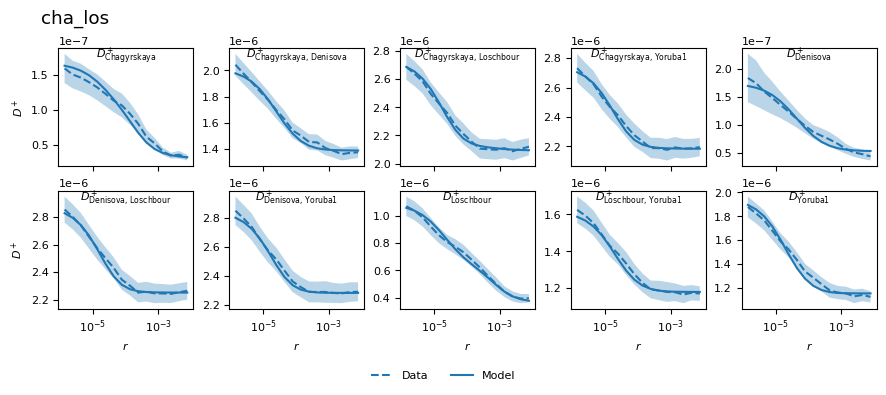

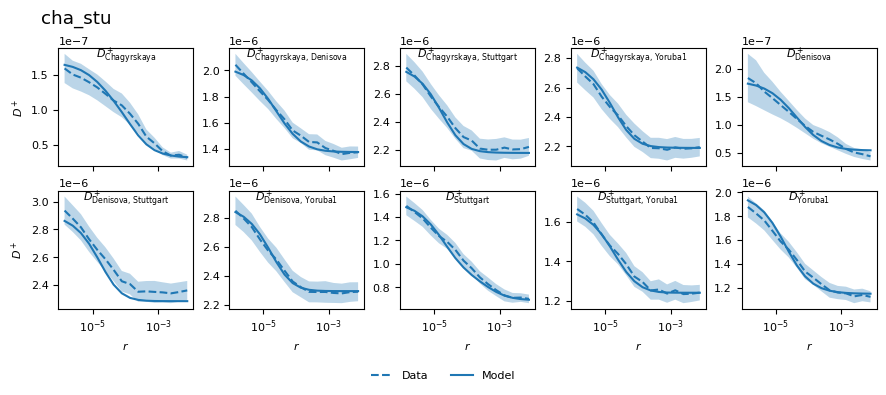

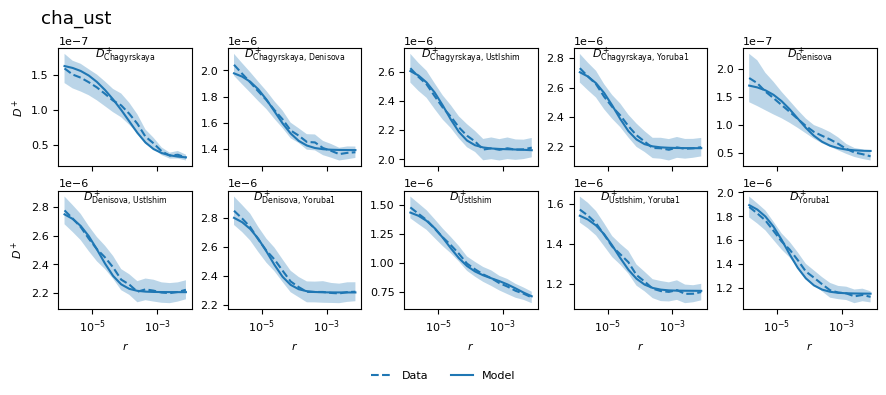

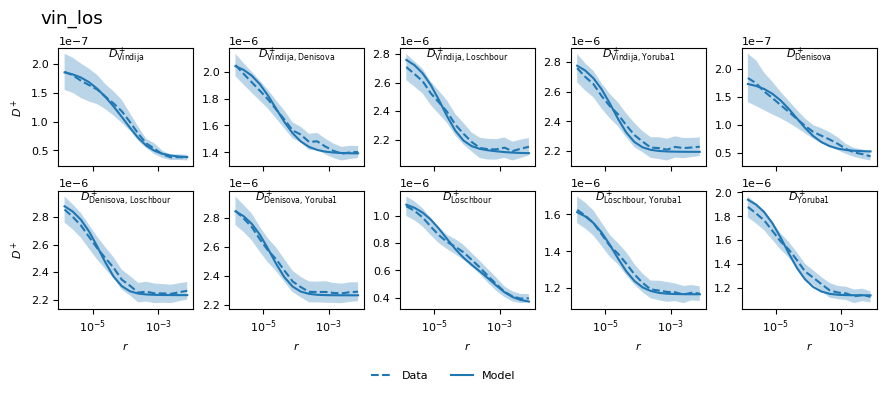

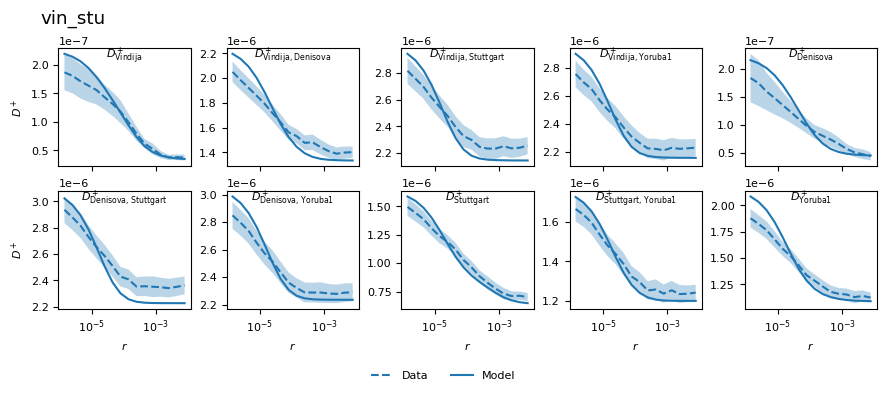

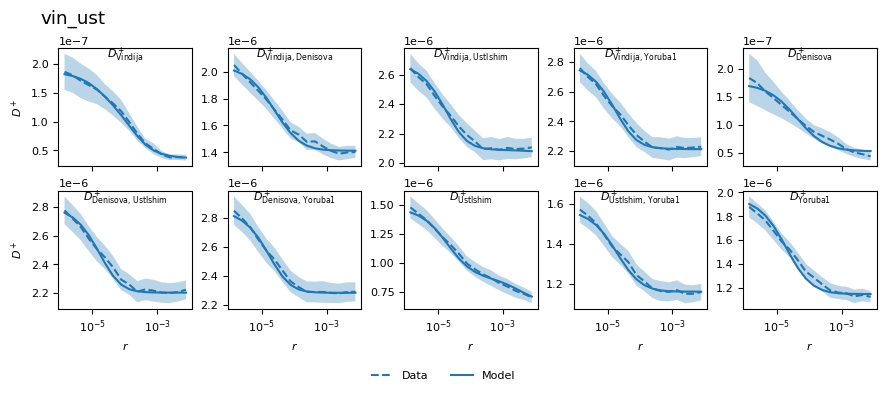

In [4]:
# Make some figures

for dataset in datasets:
    for model in model_names:
        dpluspy.plotting.plot_D_plus_curves(
            models=models[(model, dataset)],
            means=datas[(model, dataset)]["means"],
            varcovs=datas[(model, dataset)]["varcovs"],
            bins=datas[(model, dataset)]["bins"],
            pop_ids=datas[(model, dataset)]["pop_ids"],
            out=f"figures/best_fit_{model}_{dataset}.pdf",
            show=False, ax_size=1.75, cols=5,
            title=model
        )

In [6]:
# Compute uncerts

uncerts_tbl = []
params_tbl = []

for dataset in ["Bherer"]:
    for model in model_names:
        data = datas[(model, dataset)]
        graph = f"results/{model}_{dataset}.yaml"
        param_file = f"models/{model}_params.yaml"
        pnames, pvals, uncerts = dpluspy.uncerts.GIM_uncerts(
            graph,
            param_file,
            data["means"],
            data["varcovs"],
            bootreps=data["replicates"],
            pop_ids=data["pop_ids"],
            bins=data["bins"],
            u=u,
            use_bounds=True,
            verbose=False
        )
        print((model, dataset))

        params_dict = {"model": [f"{model}_{dataset}"]}
        params_dict.update(
            {pname: [pval] for pname, pval in zip(pnames, pvals)})
        params_tbl.append(pandas.DataFrame(params_dict))

        uncerts_dict = {"model": [f"{model}_{dataset}"]}
        uncerts_dict.update(
            {pname: [uncert] for pname, uncert in zip(pnames, uncerts)})
        uncerts_tbl.append(pandas.DataFrame(uncerts_dict))
            
    df_gim = pandas.concat(uncerts_tbl)
    df_mle = pandas.concat(params_tbl)
    df_gim.to_csv("GIM_uncerts.csv", index=False)
    df_mle.to_csv("best_fit_params.csv", index=False)

('alt_los', 'Bherer')
('alt_stu', 'Bherer')
('alt_ust', 'Bherer')
('cha_los', 'Bherer')
('cha_stu', 'Bherer')
('cha_ust', 'Bherer')
('vin_los', 'Bherer')
('vin_stu', 'Bherer')
('vin_ust', 'Bherer')


In [7]:
print(df_gim.columns)
print(df_gim)

Index(['model', 'T_NDH', 'T_ND', 'T_AltNI', 'T_LosOOA', 'N_Anc', 'N_AMH',
       'N_Yor', 'N_Los', 'N_ND', 'N_Den', 'N_N', 'T_pHN', 'p_HN', 'p_NH',
       'T_StuOOA', 'N_Stu', 'T_UstOOA', 'N_Ust', 'T_ChaNI', 'T_VinNI'],
      dtype='object')
            model         T_NDH          T_ND        T_AltNI      T_LosOOA  \
0  alt_los_Bherer   7335.202718   4351.811255  290392.374946  13121.499721   
0  alt_stu_Bherer  12331.379462   2395.878654   33881.396031           NaN   
0  alt_ust_Bherer   9145.890140   5714.578312  282076.016995           NaN   
0  cha_los_Bherer  19124.365417  15295.624478            NaN  14586.501969   
0  cha_stu_Bherer   8058.246042   5181.459509            NaN           NaN   
0  cha_ust_Bherer  28143.582162  26195.492801            NaN           NaN   
0  vin_los_Bherer   3479.146866   3858.174526            NaN  13343.085325   
0  vin_stu_Bherer  30089.646063  49504.779003            NaN           NaN   
0  vin_ust_Bherer   8680.897262  10561.083600           

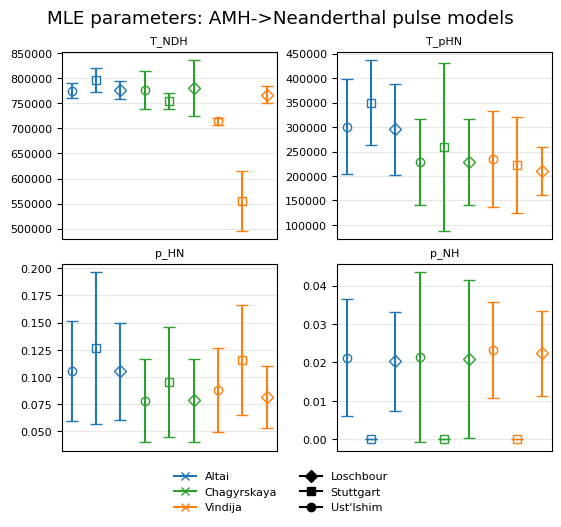

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(5.5, 4.5), layout="constrained",
    sharex=True)
axs = axs.flat

for ax in axs:
    ax.grid(alpha=0.3)

plot_params = ["T_NDH", "T_pHN", "p_HN", "p_NH"]

for ii, param in enumerate(plot_params):
    ax = axs[ii]
    ax.xaxis.set_visible(False)
    ax.set_title(param)
    for jj, model in enumerate(df_mle["model"]):
        neanderthal, african, _ = model.split("_")
        color = {"alt": "tab:blue", "vin": "tab:orange", 
            "cha": "tab:green"}[neanderthal]
        marker = {"los": "o", "stu": "s", "ust": "D"}[african]
        ax.errorbar(
            [jj], 
            df_mle[df_mle["model"] == model][param], 
            yerr=1.96 * df_gim[df_gim["model"] == model][param], 
            fmt=marker,
            color=color,
            markerfacecolor="none",
            capsize=4
        )

from matplotlib.lines import Line2D
symbols = [
    Line2D([0], [0], color="tab:blue", marker="x"),
    Line2D([0], [0], color="tab:green", marker="x"),
    Line2D([0], [0], color="tab:orange", marker="x"),
    Line2D([0], [0], color="black", marker="D"),
    Line2D([0], [0], color="black", marker="s"),
    Line2D([0], [0], color="black", marker="o"),
]
handles = [
    "Altai",
    "Chagyrskaya",
    "Vindija", 
    "Loschbour",
    "Stuttgart",
    "Ust'Ishim",
]
fig.legend(symbols, handles, framealpha=0, loc="lower center", ncols=2,
    bbox_to_anchor=[0.5, -0.15])

fig.suptitle("MLE parameters: AMH->Neanderthal pulse models")
plt.savefig("figures/parameter_uncerts.pdf")